In [2]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [3]:
SEED: int = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Data pipeline

In [8]:
def load_dataset(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

def filter_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Removes network-specific socket features and junk columns
    to prevent model overfitting.
    """
    df.columns = df.columns.str.strip()
    columns_to_drop: list[str] = [
        'Unnamed: 0',
        'Flow ID',
        'Source IP',
        'Source Port',
        'Destination IP',
        'Destination Port',
        'Timestamp',
        'Fwd Header Length.1',
        'SimillarHTTP',
        'Inbound'
    ]
    existing_columns_to_drop: list[str] = [col for col in columns_to_drop if col in df.columns]
    filtered_df: pd.DataFrame = df.drop(existing_columns_to_drop, axis=1)

    return filtered_df

def clean_missing_and_infinite_values(df: pd.DataFrame) -> pd.DataFrame:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(axis=0, how="any", inplace=True)

    return df

def encode_labels(df: pd.DataFrame) -> pd.DataFrame:
    df["Label"] = df["Label"].astype(str).str.strip().str.upper()
    df["Label"] = (df["Label"] != "BENIGN").astype(int)
    return df


In [9]:
def load_and_concat_datasets(directory_path: str, samples_per_file: int = 15_000) -> pd.DataFrame:
    processed_dfs: list[pd.DataFrame] = []
    for filename in os.listdir(directory_path):
        if filename.endswith(".csv"):
            file_path: str = os.path.join(directory_path, filename)
            temp_df: pd.DataFrame = load_dataset(file_path)
            temp_df = filter_features(temp_df)
            temp_df = clean_missing_and_infinite_values(temp_df)

            if len(temp_df) > samples_per_file:
                temp_df = temp_df.sample(n=samples_per_file, random_state=SEED)
            else:
                temp_df = temp_df.sample(frac=1.0, random_state=SEED)
            encode_labels(temp_df)
            processed_dfs.append(temp_df)

    master_df: pd.DataFrame = pd.concat(processed_dfs, ignore_index=True)
    return master_df

In [4]:
DATA_DIR: str = "data/01-12"
MASTER_DATASET_PATH: str = "data/master_clean_dataset.csv"

if os.path.exists(MASTER_DATASET_PATH):
    master_df: pd.DataFrame = pd.read_csv(MASTER_DATASET_PATH)
else:
    master_df: pd.DataFrame = load_and_concat_datasets(DATA_DIR)
    master_df.to_csv(MASTER_DATASET_PATH, index=False)
print(master_df.shape)
print(master_df.head())


(165000, 78)
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0        17              1                  2                       0   
1        17              1                  2                       0   
2        17              1                  2                       0   
3        17              1                  2                       0   
4        17              1                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                        856.0                          0.0   
1                       2928.0                          0.0   
2                       2944.0                          0.0   
3                       2832.0                          0.0   
4                       2896.0                          0.0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                  428.0                  428.0                   428.0   
1                 1

In [5]:
def split_dataframe(df: pd.DataFrame, train_frac: float = 0.7) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    X: np.ndarray = df.drop("Label", axis=1).values
    y: np.ndarray = df["Label"].values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(1.0-train_frac), random_state=SEED, stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
    )

    return X_train, y_train, X_val, y_val, X_test, y_test

def normalize(X_train: np.ndarray, X_val: np.ndarray, X_test: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    scaler: MinMaxScaler = MinMaxScaler(feature_range=(0,1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_val_scaled, X_test_scaled

X_train, y_train, X_val, y_val, X_test, y_test = split_dataframe(master_df)
X_train, X_val, X_test = normalize(X_train, X_val, X_test)



In [6]:
class DDOSDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index: int):
        return self.X[index], self.y[index]

In [7]:
train_dataset = DDOSDataset(X_train, y_train)
valid_dataset = DDOSDataset(X_val, y_val)
test_dataset = DDOSDataset(X_test, y_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
sample_inputs, sample_labels = next(iter(train_loader))
input_dim = sample_inputs.shape[-1]
input_dim

77

# Modele

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

print(f"Dostępność GPU: {torch.cuda.is_available()}")
print(f"Typ GPU: {torch.cuda.get_device_name(0)}")

Dostępność GPU: True
Typ GPU: NVIDIA GeForce RTX 4070 SUPER


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
device

device(type='cuda')

## Klasy modeli

In [9]:
class DDoSNetEncoder(nn.Module):
    def __init__(self, input_dim):
        super(DDoSNetEncoder, self).__init__()
        self.rnn1 = nn.RNN(input_size=input_dim, hidden_size=64, batch_first=True, nonlinearity='relu')
        self.rnn2 = nn.RNN(input_size=64, hidden_size=32, batch_first=True, nonlinearity='relu')
        self.rnn3 = nn.RNN(input_size=32, hidden_size=16, batch_first=True, nonlinearity='relu')
        self.rnn4 = nn.RNN(input_size=16, hidden_size=8, batch_first=True, nonlinearity='relu')

    def forward(self, x):
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        x, _ = self.rnn3(x)
        x, _ = self.rnn4(x)
        return x

In [10]:
class DDoSNetDecoder(nn.Module):
    def __init__(self, output_dim):
        super(DDoSNetDecoder, self).__init__()
        self.rnn1 = nn.RNN(input_size=8, hidden_size=8, batch_first=True, nonlinearity='relu')
        self.rnn2 = nn.RNN(input_size=8, hidden_size=16, batch_first=True, nonlinearity='relu')
        self.rnn3 = nn.RNN(input_size=16, hidden_size=32, batch_first=True, nonlinearity='relu')
        self.rnn4 = nn.RNN(input_size=32, hidden_size=64, batch_first=True, nonlinearity='relu')

        self.reconstruction_layer = nn.Linear(64, output_dim)

    def forward(self, x):
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        x, _ = self.rnn3(x)
        x, _ = self.rnn4(x)

        reconstructed = self.reconstruction_layer(x)
        return reconstructed

In [11]:
class DDoSNetReconstruction(nn.Module):
    def __init__(self, input_dim, encoder=None, decoder=None):
        super(DDoSNetReconstruction, self).__init__()

        self.encoder = encoder if encoder is not None else DDoSNetEncoder(input_dim)
        self.decoder = decoder if decoder is not None else DDoSNetDecoder(input_dim)

    def forward(self, x):
        encoded_sequence = self.encoder(x)
        reconstructed_sequence = self.decoder(encoded_sequence)

        return reconstructed_sequence

In [49]:

class DDoSNetClassifier(nn.Module):
    def __init__(self, input_dim, encoder=None, decoder=None):
        super(DDoSNetClassifier, self).__init__()

        self.encoder = encoder if encoder is not None else DDoSNetEncoder(input_dim)
        self.decoder = decoder if decoder is not None else DDoSNetDecoder(input_dim)

        self.classifier = nn.Linear(input_dim, 2)

    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)

        last_step_reconstructed = reconstructed[:, -1, :]
        logits = self.classifier(last_step_reconstructed)

        return logits

## Trenowanie

In [57]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### Funkcje trenujące 

In [40]:
def pretrain_autoencoder(model, train_loader, val_loader, device, epochs=50, lr=0.0001, save_dir="./saved_models"):
    """
    ETAP 1: Unsupervised Pre-training
    Cel: Nauczenie sieci rekonstrukcji ruchu sieciowego (bez etykiet).
    """
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_autoencoder_full.pth")
    best_encoder_path = os.path.join(save_dir, "best_encoder_only.pth")


    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    train_losses = [None]*epochs
    val_losses = [None]*epochs

    model.to(device)

    print("--- ROZPOCZĘCIE ETAPU 1: Nienadzorowany Pre-training ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for inputs, _ in tqdm(train_loader):
            inputs = inputs.to(device)
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)

            optimizer.zero_grad()

            reconstructed = model(inputs)

            loss = criterion(reconstructed, inputs)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
        
        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses[epoch] = avg_train_loss

        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for inputs, _ in val_loader:
                inputs = inputs.to(device)
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(1)
                
                reconstructed = model(inputs)
                loss = criterion(reconstructed, inputs)
                
                val_loss += loss.item() * inputs.size(0)
                
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses[epoch] = avg_val_loss
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)
            torch.save(model.encoder.state_dict(), best_encoder_path)

    print(f"\nTrening zakończony. Najlepszy błąd walidacji: {best_val_loss:.6f}")
    print(f"Pełny model zapisano w: {best_model_path}")
    print(f"Sam koder zapisano w: {best_encoder_path}")



    print("--- ZAKOŃCZONO ETAP 1 ---\n")
    return model, (train_losses, val_losses)

In [52]:
def finetune_classifier(model, train_loader, val_loader, device, epochs=50, lr=0.0001):
    """
    ETAP 2: Supervised Fine-tuning
    Cel: Klasyfikacja ruchu (Normalny vs Atak) z wykorzystaniem etykiet
         i optymalizacja wag całej sieci.
    """
    print("--- ROZPOCZĘCIE ETAPU 2: Nadzorowany Fine-tuning ---")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    train_losses = [None]*epochs
    val_losses = [None]*epochs
    train_acc = [None]*epochs
    val_acc = [None]*epochs

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).long()
            if inputs.dim() == 2:
                inputs = inputs.unsqueeze(1)
            

            optimizer.zero_grad()

            logits = model(inputs)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / total
        epoch_train_acc = train_correct / total
        train_losses[epoch] = epoch_train_loss
        train_acc[epoch] = epoch_train_acc

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                if inputs.dim() == 2:
                    inputs = inputs.unsqueeze(1)

                logits = model(inputs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(logits.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses[epoch] = epoch_val_loss
        val_acc[epoch] = epoch_val_acc

        print(f'Fine-tuning Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

    print("\nTrening zakończony. Ładowanie najlepszego modelu z Etapu 2...")
    model.load_state_dict(best_model_weights)
    return model, (train_losses, val_losses), (train_acc, val_acc)


In [58]:
def plot_learning_curves(train_losses, val_losses):
    """
    Rysuje wykres błędu treningowego i walidacyjnego.
    train_losses: lista wartości avg_train_loss z kolejnych epok
    val_losses: lista wartości avg_val_loss z kolejnych epok
    """
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_losses, 'b-', label='Trening (Train Loss)', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, 'r-', label='Walidacja (Val Loss)', linewidth=2, marker='s', markersize=4)
    
    plt.title('Krzywe uczenia modelu', fontsize=14, pad=15)
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel('Strata (Loss - MSE)', fontsize=12)
    
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.xticks(epochs)
    
    plt.tight_layout()
    plt.show()


In [42]:
def plot_accuracy_curves(train_accs, val_accs):
    """
    Rysuje wykres dokładności treningowej i walidacyjnej.
    train_accs: lista wartości avg_train_acc z kolejnych epok
    val_accs: lista wartości avg_val_acc z kolejnych epok
    """
    epochs = range(1, len(train_accs) + 1)
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_accs, 'g-', label='Trening (Train Acc)', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_accs, 'darkorange', label='Walidacja (Val Acc)', linewidth=2, marker='s', markersize=4)
    
    plt.title('Krzywe dokładności modelu (Accuracy)', fontsize=14, pad=15)
    plt.xlabel('Epoki', fontsize=12)
    plt.ylabel('Dokładność (Accuracy)', fontsize=12)
    
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.xticks(epochs)
    
    plt.ylim(0.0, 1.05)
    
    plt.tight_layout()
    plt.show()

In [61]:
def evaluate_and_plot_confusion_matrix(model, test_loader, device):
    """
    Ewaluuje model na zbiorze testowym, oblicza metryki i rysuje macierz pomyłek.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            inputs = inputs.unsqueeze(1)
            
            logits = model(inputs)
            
            _, predicted = torch.max(logits.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    print(f"\nOstateczna dokładność (Accuracy) na zbiorze testowym: {acc:.4f}")
    
    print("\nRaport Klasyfikacji:")
    print(classification_report(all_labels, all_preds, target_names=["Normalny (0)", "Atak (1)"]))
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Przewidziano: Normalny", "Przewidziano: Atak"],
                yticklabels=["Faktycznie: Normalny", "Faktycznie: Atak"])
    
    plt.title('Macierz Pomyłek (Confusion Matrix) - Zbiór Testowy', fontsize=14, pad=15)
    plt.ylabel('Prawdziwe etykiety', fontsize=12)
    plt.xlabel('Etykiety przewidziane przez model', fontsize=12)
    
    plt.tight_layout()
    plt.show()


### Trenowanie rekonstrukcji

In [43]:
model_reconstruction = DDoSNetReconstruction(input_dim=input_dim)

In [44]:
pretrained_model, losses1 = pretrain_autoencoder(model_reconstruction, train_loader, val_loader, device, epochs=50, lr=0.0001)

--- ROZPOCZĘCIE ETAPU 1: Nienadzorowany Pre-training ---


100%|██████████| 3610/3610 [00:13<00:00, 271.56it/s]


Epoch 01/50 | Train Loss: 0.008023 | Val Loss: 0.003036


100%|██████████| 3610/3610 [00:13<00:00, 262.48it/s]


Epoch 02/50 | Train Loss: 0.001968 | Val Loss: 0.000766


...

Epoch 48/50 | Train Loss: 0.000043 | Val Loss: 0.000065


100%|██████████| 3610/3610 [00:13<00:00, 263.60it/s]


Epoch 49/50 | Train Loss: 0.000042 | Val Loss: 0.000061


100%|██████████| 3610/3610 [00:13<00:00, 257.89it/s]


Epoch 50/50 | Train Loss: 0.000042 | Val Loss: 0.000063

Trening zakończony. Najlepszy błąd walidacji: 0.000061
Pełny model zapisano w: ./saved_models\best_autoencoder_full.pth
Sam koder zapisano w: ./saved_models\best_encoder_only.pth
--- ZAKOŃCZONO ETAP 1 ---



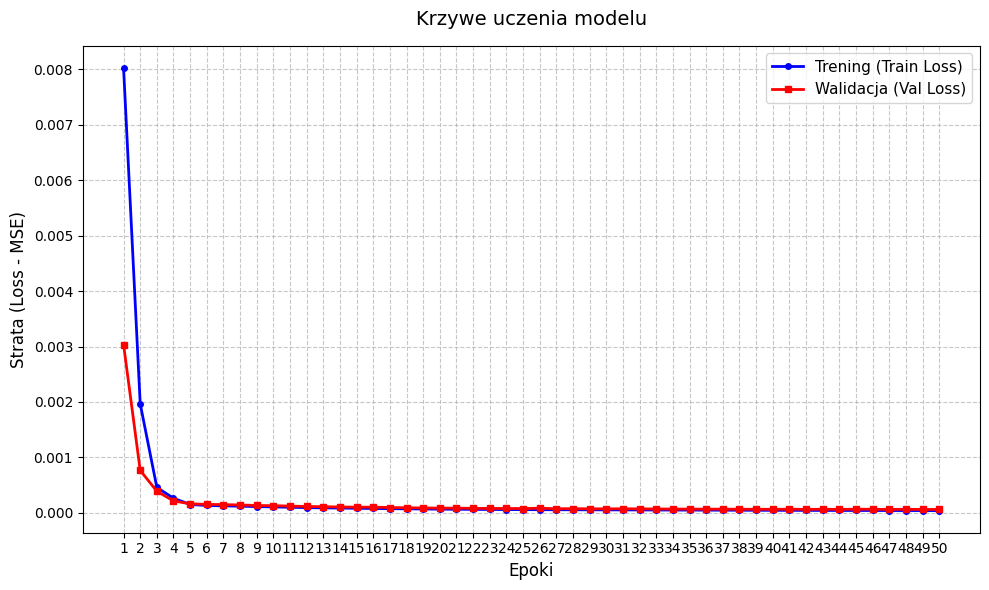

In [45]:
plot_learning_curves(*losses1)

### Trenowanie klasyfikacji

In [46]:
loaded_reconstruction_model = DDoSNetReconstruction(input_dim=input_dim)
saved_model_path = "./saved_models/best_autoencoder_full.pth"

loaded_reconstruction_model.load_state_dict(
    torch.load(saved_model_path, map_location=device)
)

<All keys matched successfully>

In [53]:
pretrained_encoder = loaded_reconstruction_model.encoder
pretrained_decoder = loaded_reconstruction_model.decoder

classifier_model = DDoSNetClassifier(
    input_dim=input_dim,
    encoder=pretrained_encoder,
    decoder=pretrained_decoder
)

In [54]:
final_model, losses2, accuraties = finetune_classifier(classifier_model, train_loader, val_loader, device, epochs=50, lr=0.0001)

--- ROZPOCZĘCIE ETAPU 2: Nadzorowany Fine-tuning ---


100%|██████████| 3610/3610 [00:13<00:00, 264.27it/s]


Fine-tuning Epoch 1/50 | Train Loss: 0.0078 Acc: 0.9979 | Val Loss: 0.0037 Acc: 0.9988


100%|██████████| 3610/3610 [00:13<00:00, 263.87it/s]


Fine-tuning Epoch 2/50 | Train Loss: 0.0025 Acc: 0.9992 | Val Loss: 0.0031 Acc: 0.9990


...

Fine-tuning Epoch 48/50 | Train Loss: 0.0009 Acc: 0.9996 | Val Loss: 0.0026 Acc: 0.9994


100%|██████████| 3610/3610 [00:13<00:00, 265.27it/s]


Fine-tuning Epoch 49/50 | Train Loss: 0.0009 Acc: 0.9995 | Val Loss: 0.0020 Acc: 0.9994


100%|██████████| 3610/3610 [00:13<00:00, 273.90it/s]


Fine-tuning Epoch 50/50 | Train Loss: 0.0009 Acc: 0.9996 | Val Loss: 0.0026 Acc: 0.9994

Trening zakończony. Ładowanie najlepszego modelu z Etapu 2...


In [64]:
torch.save(final_model.state_dict(), os.path.join("./saved_models", "best_classifier.pth"))

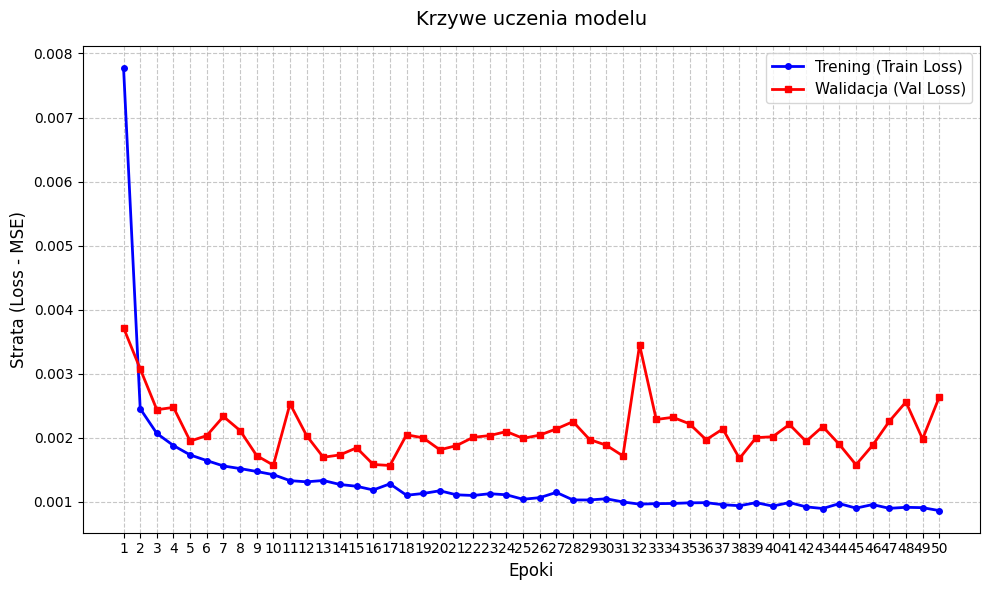

In [55]:
plot_learning_curves(*losses2)

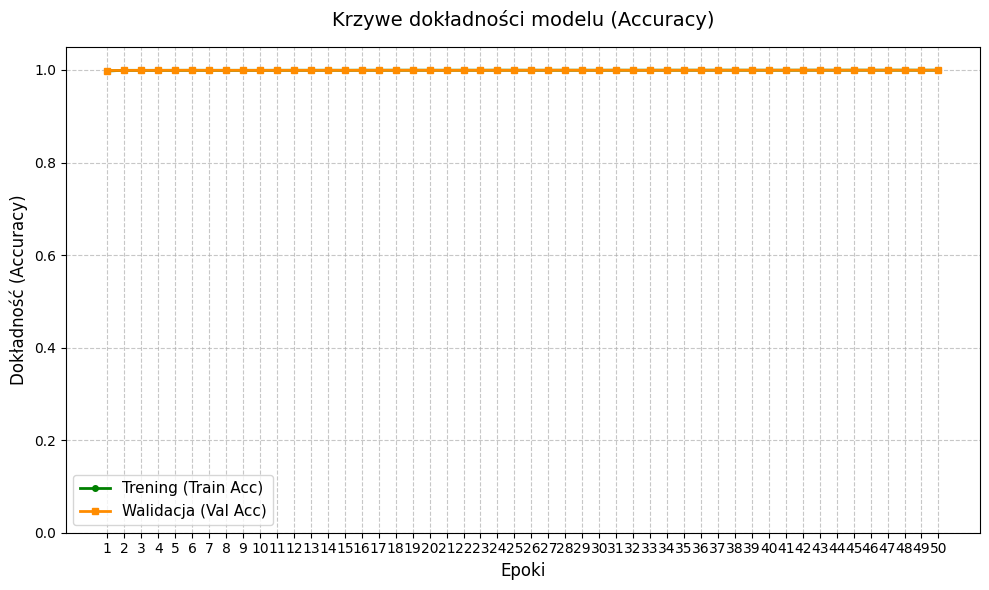

In [56]:
plot_accuracy_curves(*accuraties)


Ostateczna dokładność (Accuracy) na zbiorze testowym: 0.9992

Raport Klasyfikacji:
              precision    recall  f1-score   support

Normalny (0)       0.79      0.95      0.87        64
    Atak (1)       1.00      1.00      1.00     24687

    accuracy                           1.00     24751
   macro avg       0.90      0.98      0.93     24751
weighted avg       1.00      1.00      1.00     24751



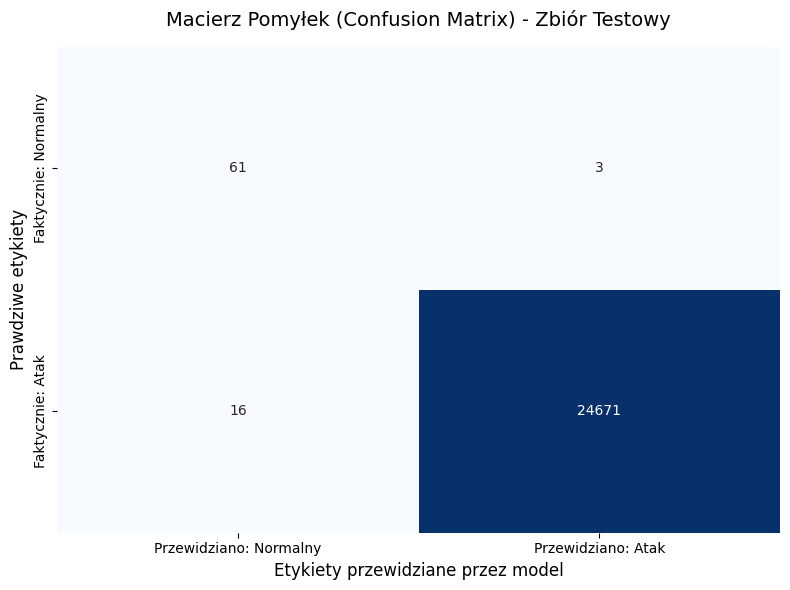

In [62]:
evaluate_and_plot_confusion_matrix(final_model, test_loader, device)